In [ ]:
import numpy as np
import pandas as pd

from src.config import RAW_DATA_DIR
from src.preprocessing.cleaning.pipeline import Cleaner
from src.preprocessing.utils import load_data
from src.visualization.analysis import (
    plot_causes_distr,
    plot_class_events, 
    plot_wildfire_distr,
    plot_missing_values,
)

pd.set_option('display.max_columns', None)

/home/cgmaew/miniconda3/envs/geok/lib/python3.11/site-packages/dython/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


In [ ]:
df_raw = load_data(RAW_DATA_DIR / "FPA_FOD_20221014.sqlite")  

df_raw.head()

,OBJECTID,Shape,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,LOCAL_FIRE_REPORT_ID,LOCAL_INCIDENT_ID,FIRE_CODE,FIRE_NAME,ICS_209_PLUS_INCIDENT_JOIN_ID,ICS_209_PLUS_COMPLEX_JOIN_ID,MTBS_ID,MTBS_FIRE_NAME,COMPLEX_NAME,FIRE_YEAR,DISCOVERY_DATE,DISCOVERY_DOY,DISCOVERY_TIME,NWCG_CAUSE_CLASSIFICATION,NWCG_GENERAL_CAUSE,NWCG_CAUSE_AGE_CATEGORY,CONT_DATE,CONT_DOY,CONT_TIME,FIRE_SIZE,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME
0,1,b'\x00\x01\xad\x10\x00\x00\xc8\xce\n[_@^\xc0\x...,1,FS-1418826,FED,FS-FIRESTAT,FS,USCAPNF,Plumas National Forest,0511,Plumas National Forest,1,PNF-47,BJ8K,FOUNTAIN,None,None,None,None,None,2005,2/2/2005,33,1300,Human,Power generation/transmission/distribution,None,2/2/2005,33.0,1730,0.10,A,40.036944,-121.005833,USFS,CA,63,06063,Plumas County
1,2,b'\x00\x01\xad\x10\x00\x00\xc8\xe594\xe2\x19^\...,2,FS-1418827,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,13,13,AAC0,PIGEON,None,None,None,None,None,2004,5/12/2004,133,0845,Natural,Natural,None,5/12/2004,133.0,1530,0.25,A,38.933056,-120.404444,USFS,CA,61,06061,Placer County
2,3,b'\x00\x01\xad\x10\x00\x00x{\xac \x13/^\xc0@\x...,3,FS-1418835,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,27,021,A32W,SLACK,None,None,None,None,None,2004,5/31/2004,152,1921,Human,Debris and open burning,None,5/31/2004,152.0,2024,0.10,A,38.984167,-120.735556,STATE OR PRIVATE,CA,17,06017,El Dorado County
3,4,b'\x00\x01\xad\x10\x00\x00\xc8\x13u\xd7s\xfa]\...,4,FS-1418845,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,43,6,None,DEER,None,None,None,None,None,2004,6/28/2004,180,1600,Natural,Natural,None,7/3/2004,185.0,1400,0.10,A,38.559167,-119.913333,USFS,CA,3,06003,Alpine County
4,5,b'\x00\x01\xad\x10\x00\x00\xd0\x11y\xf8\xb6\xf...,5,FS-1418847,FED,FS-FIRESTAT,FS,USCAENF,Eldorado National Forest,0503,Eldorado National Forest,44,7,None,STEVENOT,None,None,None,None,None,2004,6/28/2004,180,1600,Natural,Natural,None,7/3/2004,185.0,1200,0.10,A,38.559167,-119.933056,USFS,CA,3,06003,Alpine County


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2303566 entries, 0 to 2303565
Data columns (total 39 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   OBJECTID                       int64  
 1   Shape                          object 
 2   FOD_ID                         int64  
 3   FPA_ID                         object 
 4   SOURCE_SYSTEM_TYPE             object 
 5   SOURCE_SYSTEM                  object 
 6   NWCG_REPORTING_AGENCY          object 
 7   NWCG_REPORTING_UNIT_ID         object 
 8   NWCG_REPORTING_UNIT_NAME       object 
 9   SOURCE_REPORTING_UNIT          object 
 10  SOURCE_REPORTING_UNIT_NAME     object 
 11  LOCAL_FIRE_REPORT_ID           object 
 12  LOCAL_INCIDENT_ID              object 
 13  FIRE_CODE                      object 
 14  FIRE_NAME                      object 
 15  ICS_209_PLUS_INCIDENT_JOIN_ID  object 
 16  ICS_209_PLUS_COMPLEX_JOIN_ID   object 
 17  MTBS_ID                        object 
 18  MT

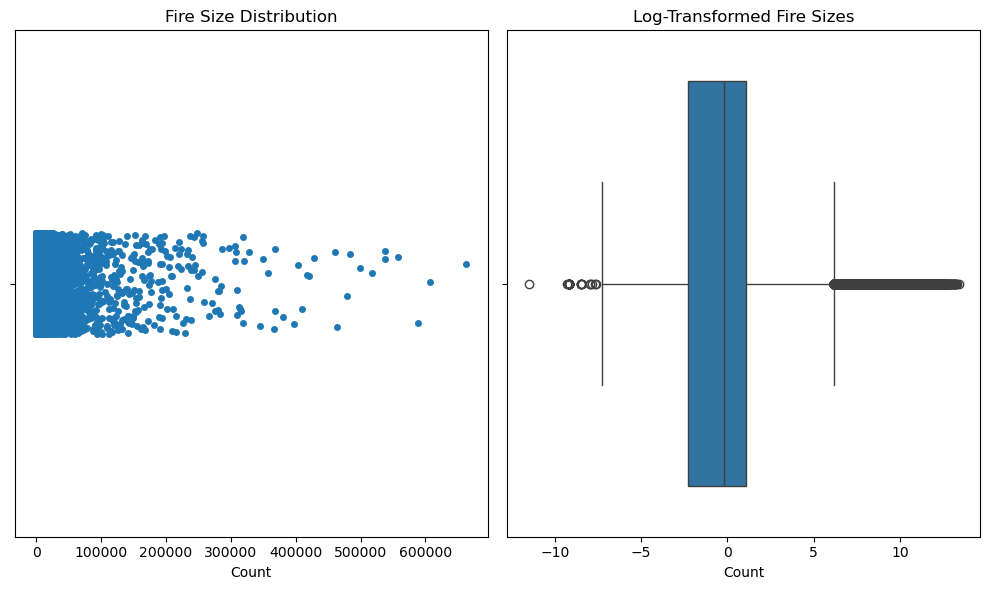

In [ ]:
plot_wildfire_distr(df_raw.FIRE_SIZE)

In [5]:
display(df_raw.describe())
df_raw.describe(exclude=np.number)

,OBJECTID,FOD_ID,FIRE_YEAR,DISCOVERY_DOY,CONT_DOY,FIRE_SIZE,LATITUDE,LONGITUDE
count,2.303566e+06,2.303566e+06,2.303566e+06,2.303566e+06,1.408753e+06,2.303566e+06,2.303566e+06,2.303566e+06
mean,1.151784e+06,1.185100e+08,2.006167e+03,1.659714e+02,1.707579e+02,7.816088e+01,3.696623e+01,-9.635792e+01
std,6.649824e+05,1.621564e+08,8.044361e+00,8.975278e+01,8.626373e+01,2.630832e+03,6.008260e+00,1.664360e+01
min,1.000000e+00,1.000000e+00,1.992000e+03,1.000000e+00,1.000000e+00,1.000000e-05,1.793972e+01,-1.788026e+02
25%,5.758922e+05,6.225492e+05,2.000000e+03,9.100000e+01,9.900000e+01,1.000000e-01,3.301390e+01,-1.110361e+02
50%,1.151784e+06,1.403630e+06,2.006000e+03,1.660000e+02,1.760000e+02,8.000000e-01,3.572250e+01,-9.347009e+01
75%,1.727675e+06,3.000071e+08,2.013000e+03,2.310000e+02,2.320000e+02,3.000000e+00,4.089029e+01,-8.251000e+01
max,2.303566e+06,4.007330e+08,2.020000e+03,3.660000e+02,3.660000e+02,6.627000e+05,7.033060e+01,-6.525694e+01


,Shape,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,SOURCE_REPORTING_UNIT_NAME,LOCAL_FIRE_REPORT_ID,LOCAL_INCIDENT_ID,FIRE_CODE,FIRE_NAME,ICS_209_PLUS_INCIDENT_JOIN_ID,ICS_209_PLUS_COMPLEX_JOIN_ID,MTBS_ID,MTBS_FIRE_NAME,COMPLEX_NAME,DISCOVERY_DATE,DISCOVERY_TIME,NWCG_CAUSE_CLASSIFICATION,NWCG_GENERAL_CAUSE,NWCG_CAUSE_AGE_CATEGORY,CONT_DATE,CONT_TIME,FIRE_SIZE_CLASS,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME
count,2303566,2303566,2303566,2303566,2303566,2303566,2303566,2303566,2303566,477675,1559155,397417,1339122,33494,4939,13870,13870,5947,2303566,1514471,2303566,2303566,75527,1408753,1313664,2303566,2303566,2303566,1637787,1637787,1637786
unique,1967535,2303566,3,41,12,2143,2105,6288,5203,17610,950104,230077,701434,29937,1150,13292,10009,1534,10593,1440,3,13,1,10596,1441,7,17,52,3976,2955,1805
top,b'\x00\x01\xad\x10\x00\x00\xb88MF\xc5\x8fP\xc0...,FS-1418826,NONFED,ST-NASF,ST/C&L,USGAGAS,Georgia Forestry Commission,GAGAS,Georgia Forestry Commission,001,001,D44Z,N/A,2017_7238965_MODOC JULY COMPLEX,2017_7238965_MODOC JULY COMPLEX,KY3686008359020011102,UNNAMED,MODOC JULY COMPLEX,2/10/2008,1400,Human,Missing data/not specified/undetermined,Minor,2/19/2011,1800,B,MISSING/NOT SPECIFIED,CA,Maricopa,06065,Riverside County
freq,571,1,1706587,1054112,1728168,183063,183063,113791,113791,8615,4036,9441,24240,57,59,12,784,63,1220,27093,1782906,597933,75527,865,44514,1104387,1068424,251881,13996,17159,17159


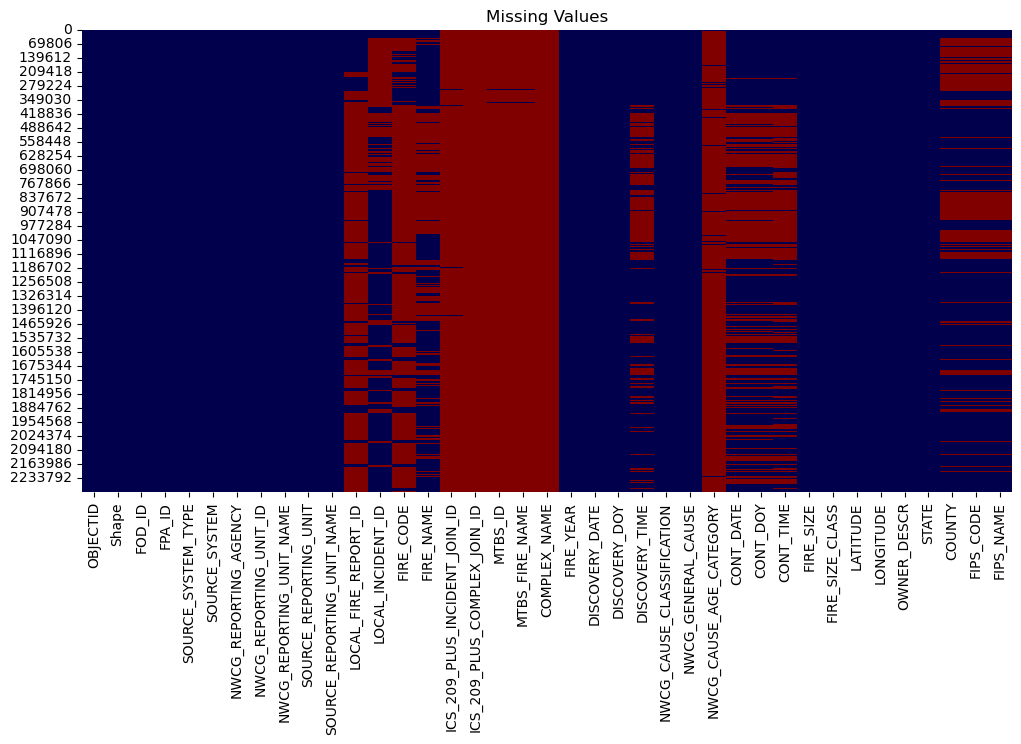

In [6]:
plot_missing_values(df_raw)

In [7]:
complexes = df_raw.COMPLEX_NAME.value_counts().index
repr(complexes[complexes.str.strip().duplicated(keep=False)])

"Index(['POWELL COMPLEX', 'POWELL COMPLEX\xa0', 'PIUTE COMPLEX', 'PIUTE COMPLEX\xa0'], dtype='object', name='COMPLEX_NAME')"

In [8]:
cols = np.r_[19, 24:27, 30:34, 35]
df_raw[
    df_raw.assign(COMPLEX_NAME=df_raw.COMPLEX_NAME.str.strip())
    .iloc[:, cols]
    .duplicated()
].take(cols, 1).tail()

,COMPLEX_NAME,NWCG_CAUSE_CLASSIFICATION,NWCG_GENERAL_CAUSE,NWCG_CAUSE_AGE_CATEGORY,FIRE_SIZE,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,STATE
2301395,None,Human,Arson/incendiarism,None,0.1,A,43.6295,-70.3191,ME
2302700,None,Human,Arson/incendiarism,None,0.1,A,31.5200,-88.2990,AL
2302726,None,Human,Missing data/not specified/undetermined,None,5.0,B,33.4820,-86.6310,AL
2302749,None,Human,Railroad operations and maintenance,None,1.0,B,33.3590,-86.1480,AL
2303149,None,Human,Arson/incendiarism,None,2.0,B,32.2640,-85.4900,AL


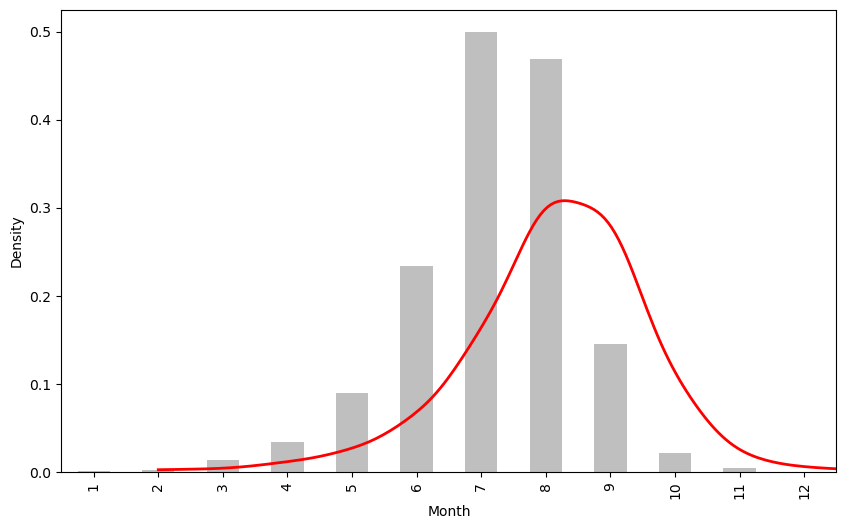

In [9]:
plot_class_events(df_raw, "Natural")

In [10]:
df_raw.NWCG_GENERAL_CAUSE.value_counts()

NWCG_GENERAL_CAUSE
Missing data/not specified/undetermined       597933
Debris and open burning                       535851
Natural                                       327319
Arson/incendiarism                            320814
Equipment and vehicle use                     190319
Recreation and ceremony                        99473
Misuse of fire by a minor                      66280
Smoking                                        63783
Railroad operations and maintenance            37292
Power generation/transmission/distribution     32652
Fireworks                                      18599
Other causes                                   10517
Firearms and explosives use                     2734
Name: count, dtype: int64

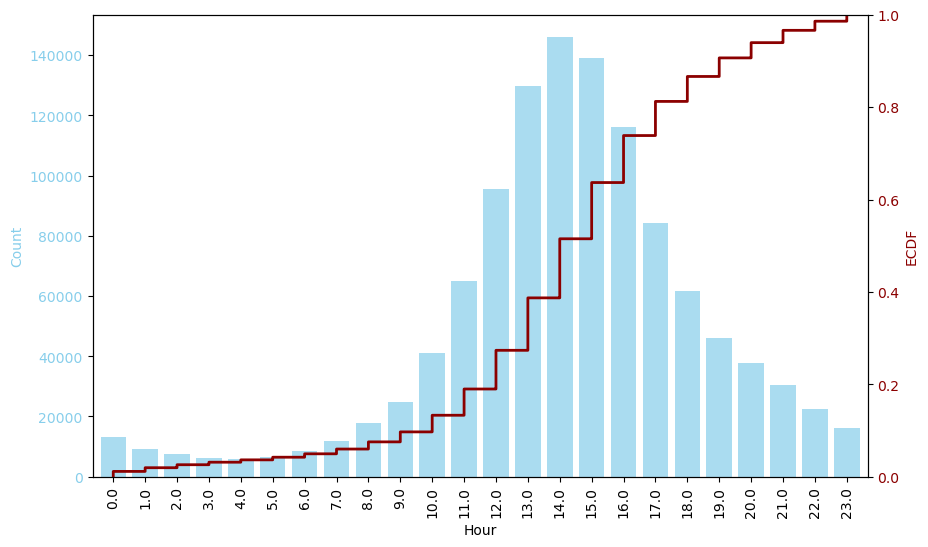

In [11]:
plot_class_events(df_raw, "Human")

In [12]:
def ids_per_name(df, col_name, col_id):
    group = df.groupby(col_name, as_index=False)[col_id].unique()
    print(group[group[col_id].apply(len) > 1])


ids_per_name(df_raw, "NWCG_REPORTING_UNIT_NAME", "NWCG_REPORTING_UNIT_ID")

               NWCG_REPORTING_UNIT_NAME                 NWCG_REPORTING_UNIT_ID
171                       Blaine County                    [USMTLG24, USIDBLX]
233                        Butte County                    [USSDBTX, USID10BN]
271                       Carbon County                    [USWYCAX, USMTLG10]
288   Cascade Volunteer Fire Department                   [USSDCADX, USCOCASX]
342                     Cheyenne County                     [USCOCYX, USKSCNX]
365                        Clark County            [USKSCAX, USSDCLX, USID5CN]
477                       Custer County           [USCOCUX, USSDCUX, USMTLG14]
538                      Douglas County            [USCODGX, USSDDOX, USKSDGX]
687                      Fremont County            [USCOFRX, USWYFRX, USID2FN]
695                     Garfield County                    [USCOGFX, USMTLG50]
752                 Grand Portage Tribe                     [USMNGPA, USMngpa]
925                      Jackson County             

In [13]:
num = df_raw.query("NWCG_CAUSE_AGE_CATEGORY == 'Minor'").NWCG_GENERAL_CAUSE.nunique()
print("There are %d causes by minors" % num)

There are 9 causes by minors


In [ ]:
cleaner = Cleaner()
df_clean = cleaner.clean(df_raw.copy())

df_clean.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 2299881 entries, 0 to 2303565
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   COMPLEX_NAME        2299881 non-null  category      
 1   CAUSE_CLASS         2299881 non-null  category      
 2   CAUSE               2299881 non-null  category      
 3   CAUSE_AGE           2299881 non-null  category      
 4   FIRE_SIZE           2299881 non-null  float64       
 5   FIRE_SIZE_CLASS     2299881 non-null  category      
 6   LATITUDE            2299881 non-null  float64       
 7   LONGITUDE           2299881 non-null  float64       
 8   STATE               2299881 non-null  category      
 9   DISCOVERY_DATETIME  2299881 non-null  datetime64[ns]
 10  CONT_DATETIME       2299881 non-null  datetime64[ns]
dtypes: category(6), datetime64[ns](2), float64(3)
memory usage: 120.7 MB


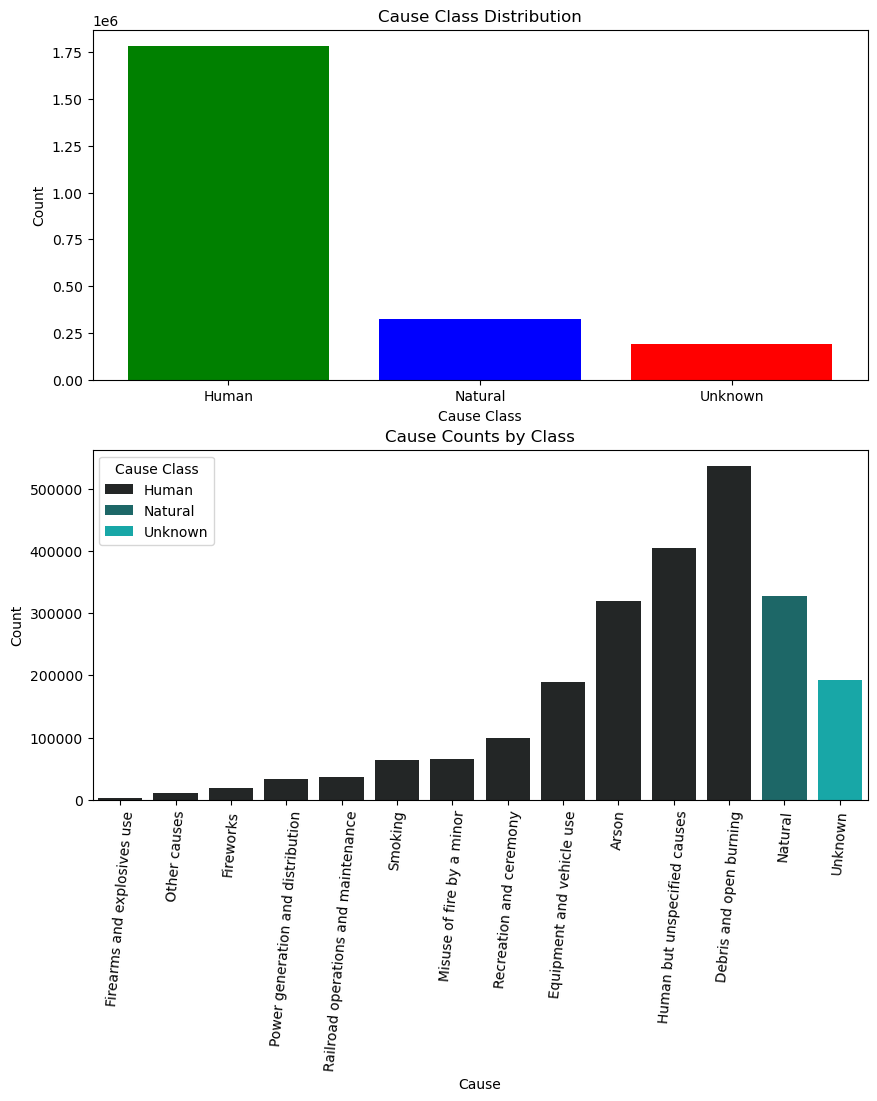

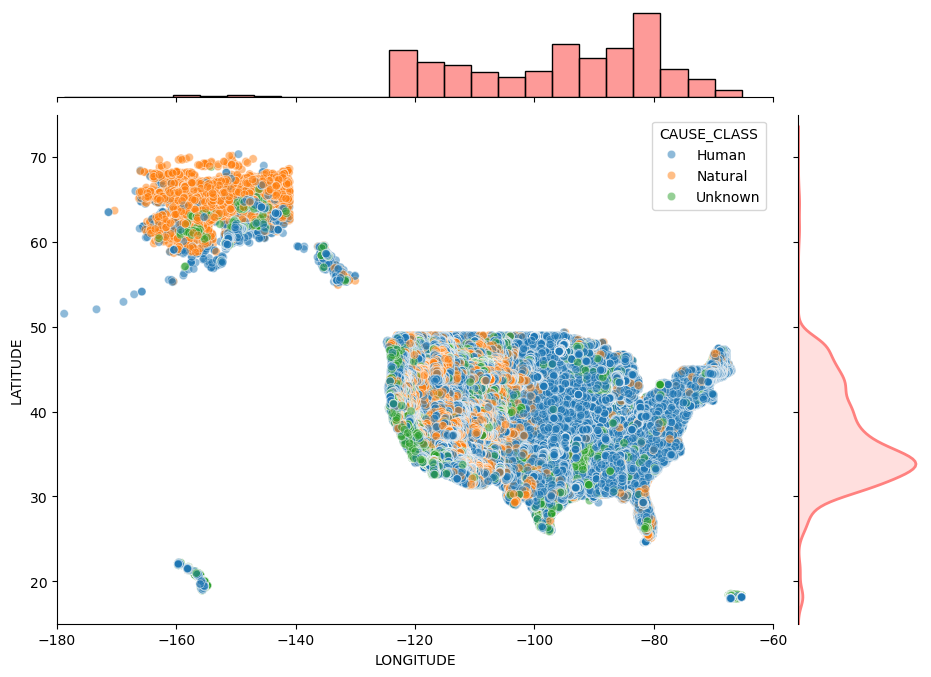

In [4]:
plot_causes_distr(df_clean.CAUSE, df_clean.CAUSE_CLASS, df_clean.LATITUDE, df_clean.LONGITUDE)